# Trabajo Final — Fundamentos y Algoritmia para Inteligencia Artificial
**Caso práctico:** DataExpert · **Dataset:** Seeds (UCI / Kaggle) — 210 semillas de trigo, 7 características, 3 variedades (1 = Kama, 2 = Rosa, 3 = Canadian).

## Esquema de la solución
```
Carga y exploración (pandas)
        ↓
Preprocesamiento: separar X / y → train/test → StandardScaler
        ↓
Álgebra lineal (NumPy): vectores, matrices, producto punto, norma, sistema Ax = b
        ↓
Estadística: media, mediana, varianza y desviación estándar (manual vs NumPy)
        ↓
Valores atípicos en Area (criterio de 2 desviaciones estándar)
        ↓
Gráficos: histograma de Area · dispersión Area vs Perimeter
        ↓
Modelos: K-Vecinos vs Árbol de Decisión → Accuracy → conclusiones
```

In [1]:
%pip install --upgrade --force-reinstall scikit-learn

  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
    -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

def caja(titulo, cuerpo):
    """Enmarca un resultado en una caja."""
    lineas = str(cuerpo).split("\n")
    w = max(len(titulo), *(len(l) for l in lineas)) + 2
    print("+" + "-" * (w + 2) + "+")
    print(f"| {titulo.ljust(w)} |")
    print("+" + "-" * (w + 2) + "+")
    for l in lineas:
        print(f"| {l.ljust(w)} |")
    print("+" + "-" * (w + 2) + "+\n")

## 1. Carga y exploración del dataset con Pandas
Sube el archivo del dataset junto al notebook y ajusta `RUTA`. Sirve el `seeds_dataset.txt` de UCI (sin encabezado) o el CSV de Kaggle (con encabezado): las columnas se renombran por posición.

In [13]:
import os

RUTA = "seeds_dataset.txt"
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"

COLS = ["Area", "Perimeter", "Compactness", "Length", "Width", "Asymmetry", "Groove", "Class"]

# Descarga el archivo si no existe localmente
if not os.path.exists(RUTA):
    import urllib.request
    urllib.request.urlretrieve(URL, RUTA)

if RUTA.endswith(".txt"):
    df = pd.read_csv(RUTA, sep=r"\s+", header=None, engine="python")
else:
    df = pd.read_csv(RUTA)

df.columns = COLS
df["Class"] = df["Class"].astype(int)

caja("Forma (filas, columnas)", df.shape)
caja("Primeras 5 filas", df.head().to_string())
caja("Las 7 características", "\n".join(COLS[:-1]))
caja("Tipos de dato", df.dtypes.to_string())
caja("Valores nulos por columna", df.isnull().sum().to_string())
caja("Balance de clases", df["Class"].value_counts().sort_index().to_string())
caja("Resumen estadístico", df.describe().round(3).to_string())

+---------------------------+
| Forma (filas, columnas)   |
+---------------------------+
| (210, 8)                  |
+---------------------------+

+-----------------------------------------------------------------------------+
| Primeras 5 filas                                                            |
+-----------------------------------------------------------------------------+
|     Area  Perimeter  Compactness  Length  Width  Asymmetry  Groove  Class   |
| 0  15.26      14.84       0.8710   5.763  3.312      2.221   5.220      1   |
| 1  14.88      14.57       0.8811   5.554  3.333      1.018   4.956      1   |
| 2  14.29      14.09       0.9050   5.291  3.337      2.699   4.825      1   |
| 3  13.84      13.94       0.8955   5.324  3.379      2.259   4.805      1   |
| 4  16.14      14.99       0.9034   5.658  3.562      1.355   5.175      1   |
+-----------------------------------------------------------------------------+

+-------------------------+
| Las 7 característi

## 2. Separar predictores y variable `Class` + normalización
`StandardScaler` se ajusta **solo con el conjunto de entrenamiento** y luego se aplica al de prueba, para evitar fuga de información (*data leakage*). Usamos `stratify=y` para que las 3 variedades queden balanceadas en ambos conjuntos.

In [14]:
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

caja("Media por característica (train escalado, ≈ 0)", np.round(X_train_s.mean(axis=0), 3))
caja("Desv. estándar por característica (train escalado, ≈ 1)", np.round(X_train_s.std(axis=0), 3))

+--------------------------------------------------+
| Media por característica (train escalado, ≈ 0)   |
+--------------------------------------------------+
| [-0. -0.  0.  0. -0.  0.  0.]                    |
+--------------------------------------------------+

+-----------------------------------------------------------+
| Desv. estándar por característica (train escalado, ≈ 1)   |
+-----------------------------------------------------------+
| [1. 1. 1. 1. 1. 1. 1.]                                    |
+-----------------------------------------------------------+



## 3. Álgebra lineal con NumPy

In [15]:
v1 = df.loc[0, COLS[:-1]].to_numpy(dtype=float)
v2 = df.loc[1, COLS[:-1]].to_numpy(dtype=float)
M = df[COLS[:-1]].to_numpy(dtype=float)

caja("Vector v1 (muestra 0)", v1)
caja("Forma de la matriz M", M.shape)
caja("Forma de la transpuesta M.T", M.T.shape)
caja("Producto punto v1 · v2", f"{np.dot(v1, v2):.4f}")
caja("Norma ||v1||", f"{np.linalg.norm(v1):.4f}")
cos = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
caja("Similitud coseno entre v1 y v2", f"{cos:.4f}")

+------------------------------------------------------+
| Vector v1 (muestra 0)                                |
+------------------------------------------------------+
| [15.26  14.84   0.871  5.763  3.312  2.221  5.22 ]   |
+------------------------------------------------------+

+------------------------+
| Forma de la matriz M   |
+------------------------+
| (210, 7)               |
+------------------------+

+-------------------------------+
| Forma de la transpuesta M.T   |
+-------------------------------+
| (7, 210)                      |
+-------------------------------+

+--------------------------+
| Producto punto v1 · v2   |
+--------------------------+
| 515.2329                 |
+--------------------------+

+----------------+
| Norma ||v1||   |
+----------------+
| 23.0264        |
+----------------+

+----------------------------------+
| Similitud coseno entre v1 y v2   |
+----------------------------------+
| 0.9986                           |
+----------------

### Sistema de ecuaciones lineales  $A\mathbf{x} = \mathbf{b}$
$$2x + y - z = 8 \qquad -3x - y + 2z = -11 \qquad -2x + y + 2z = -3$$

In [16]:
A = np.array([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]], dtype=float)
b = np.array([8, -11, -3], dtype=float)
sol = np.linalg.solve(A, b)

caja("Solución (x, y, z)", sol)
caja("Verificación: ¿A @ x == b?", np.allclose(A @ sol, b))

+----------------------+
| Solución (x, y, z)   |
+----------------------+
| [ 2.  3. -1.]        |
+----------------------+

+------------------------------+
| Verificación: ¿A @ x == b?   |
+------------------------------+
| True                         |
+------------------------------+



## 4. Estadística: media, mediana, varianza y desviación estándar
Usamos `ddof=1` (varianza **muestral**, divide entre n−1) tanto en NumPy como en la versión manual. `np.var` usa `ddof=0` por defecto: si no se aclara, los resultados no coinciden.

In [17]:
resumen = {}
for col in ["Area", "Perimeter"]:
    d = df[col].to_numpy()
    resumen[col] = {
        "media": np.mean(d),
        "mediana": np.median(d),
        "varianza (muestral)": np.var(d, ddof=1),
        "desv. estándar (muestral)": np.std(d, ddof=1),
    }
caja("Area y Perimeter", pd.DataFrame(resumen).round(4).to_string())

+-------------------------------------------------+
| Area y Perimeter                                |
+-------------------------------------------------+
|                               Area  Perimeter   |
| media                      14.8475    14.5593   |
| mediana                    14.3550    14.3200   |
| varianza (muestral)         8.4664     1.7055   |
| desv. estándar (muestral)   2.9097     1.3060   |
+-------------------------------------------------+



In [18]:
def varianza_manual(valores, muestral=True):
    """Varianza desde la definición: suma((x - media)^2) / (n-1 ó n)."""
    n = len(valores)
    media = sum(valores) / n
    suma_cuadrados = sum((x - media) ** 2 for x in valores)
    return suma_cuadrados / (n - 1 if muestral else n)

def desviacion_manual(valores, muestral=True):
    return varianza_manual(valores, muestral) ** 0.5

area = df["Area"].to_numpy()
caja("Area: manual vs NumPy",
     f"Varianza manual : {varianza_manual(area):.6f}\n"
     f"Varianza NumPy  : {np.var(area, ddof=1):.6f}\n"
     f"Desv. manual    : {desviacion_manual(area):.6f}\n"
     f"Desv. NumPy     : {np.std(area, ddof=1):.6f}\n"
     f"¿Coinciden?     : {np.isclose(varianza_manual(area), np.var(area, ddof=1))}")

+------------------------------+
| Area: manual vs NumPy        |
+------------------------------+
| Varianza manual : 8.466351   |
| Varianza NumPy  : 8.466351   |
| Desv. manual    : 2.909699   |
| Desv. NumPy     : 2.909699   |
| ¿Coinciden?     : True       |
+------------------------------+



## 5. Valores atípicos en `Area` (criterio de 2 desviaciones estándar)
Un valor es atípico si $|x-\mu| > 2\sigma$.

In [19]:
mu, sigma = area.mean(), area.std(ddof=1)
inferior, superior = mu - 2 * sigma, mu + 2 * sigma
mascara = (df["Area"] < inferior) | (df["Area"] > superior)
atipicos = df[mascara]

caja("Límites para Area (media ± 2 desv.)", f"Inferior: {inferior:.3f}\nSuperior: {superior:.3f}")
caja("Cantidad de atípicos", f"{mascara.sum()} de {len(df)} ({mascara.mean()*100:.1f}%)")
caja("Filas atípicas", atipicos[["Area", "Class"]].to_string())

+---------------------------------------+
| Límites para Area (media ± 2 desv.)   |
+---------------------------------------+
| Inferior: 9.028                       |
| Superior: 20.667                      |
+---------------------------------------+

+------------------------+
| Cantidad de atípicos   |
+------------------------+
| 4 de 210 (1.9%)        |
+------------------------+

+---------------------+
| Filas atípicas      |
+---------------------+
|       Area  Class   |
| 77   20.71      2   |
| 88   21.18      2   |
| 89   20.88      2   |
| 114  20.97      2   |
+---------------------+



## 6. Visualización

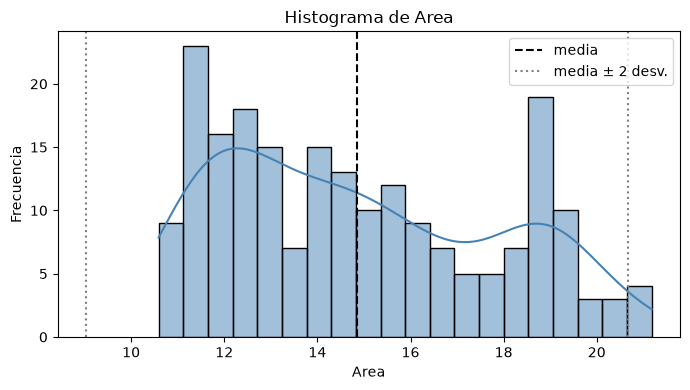

In [20]:
nombres = {1: "Kama", 2: "Rosa", 3: "Canadian"}
df["Variedad"] = df["Class"].map(nombres)

plt.figure(figsize=(7, 4))
sns.histplot(df["Area"], bins=20, kde=True, color="steelblue")
plt.axvline(mu, color="black", linestyle="--", label="media")
plt.axvline(inferior, color="gray", linestyle=":", label="media ± 2 desv.")
plt.axvline(superior, color="gray", linestyle=":")
plt.title("Histograma de Area")
plt.xlabel("Area"); plt.ylabel("Frecuencia")
plt.legend(); plt.tight_layout(); plt.show()

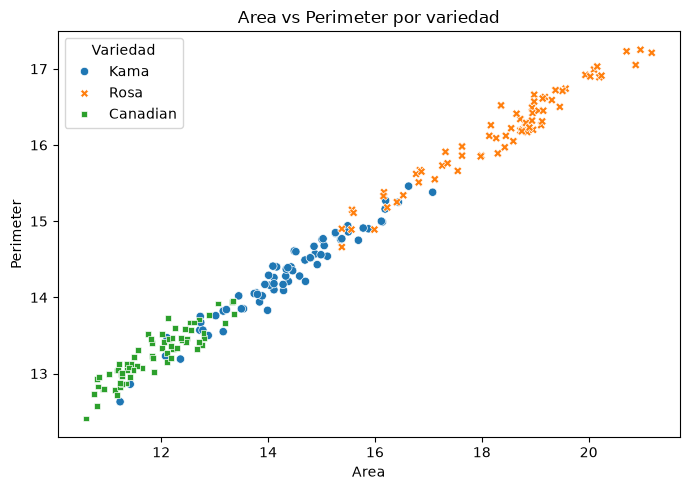

In [21]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Area", y="Perimeter", hue="Variedad", style="Variedad")
plt.title("Area vs Perimeter por variedad")
plt.tight_layout(); plt.show()

## 7. Modelos de clasificación: K-Vecinos vs Árbol de Decisión
KNN calcula distancias, así que **depende de la escala** de las variables (por eso usamos los datos normalizados). El árbol no la necesita, pero lo entrenamos con los mismos datos para comparar en igualdad de condiciones.

In [22]:
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
arbol = DecisionTreeClassifier(random_state=42).fit(X_train_s, y_train)

pred_knn = knn.predict(X_test_s)
pred_arbol = arbol.predict(X_test_s)
acc_knn = accuracy_score(y_test, pred_knn)
acc_arbol = accuracy_score(y_test, pred_arbol)

caja("Accuracy en el conjunto de prueba",
     f"K-Vecinos (k=5)    : {acc_knn:.4f}\nÁrbol de Decisión  : {acc_arbol:.4f}")
caja("Matriz de confusión — KNN", confusion_matrix(y_test, pred_knn))
caja("Matriz de confusión — Árbol", confusion_matrix(y_test, pred_arbol))

+-------------------------------------+
| Accuracy en el conjunto de prueba   |
+-------------------------------------+
| K-Vecinos (k=5)    : 0.9048         |
| Árbol de Decisión  : 0.8810         |
+-------------------------------------+

+-----------------------------+
| Matriz de confusión — KNN   |
+-----------------------------+
| [[10  2  2]                 |
|  [ 0 14  0]                 |
|  [ 0  0 14]]                |
+-----------------------------+

+-------------------------------+
| Matriz de confusión — Árbol   |
+-------------------------------+
| [[10  2  2]                   |
|  [ 1 13  0]                   |
|  [ 0  0 14]]                  |
+-------------------------------+



### Verificación con validación cruzada
Con 210 muestras, el conjunto de prueba tiene solo 42 datos y un único split puede variar varios puntos. La validación cruzada de 5 pliegues da una comparación más estable.

In [23]:
cv_knn = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(5)), X, y, cv=5)
cv_arbol = cross_val_score(make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=42)), X, y, cv=5)
caja("Accuracy con validación cruzada (media ± desv.)",
     f"K-Vecinos : {cv_knn.mean():.4f} ± {cv_knn.std():.4f}\n"
     f"Árbol     : {cv_arbol.mean():.4f} ± {cv_arbol.std():.4f}")

+---------------------------------------------------+
| Accuracy con validación cruzada (media ± desv.)   |
+---------------------------------------------------+
| K-Vecinos : 0.9143 ± 0.0667                       |
| Árbol     : 0.8857 ± 0.0410                       |
+---------------------------------------------------+

